In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
import pandas as pd
import os

# Set working directory to project root
os.chdir(r'C:\10x AIMastery\fraud-detection-10academy')


merged = pd.read_csv("data/processed/fraud_data_with_country.csv")  # or your actual path


In [8]:
from sklearn.model_selection import train_test_split

# Drop unneeded columns and define X, y
features = merged.drop(columns=['user_id', 'device_id', 'signup_time', 'purchase_time', 'class'])
target = merged['class']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, stratify=target, random_state=42)


In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "SVM": SVC()
}


In [11]:
from sklearn.model_selection import train_test_split

# Assuming `merged` is your final dataset with all features engineered
features = merged.drop(columns=['user_id', 'device_id', 'signup_time', 'purchase_time', 'class'])
target = merged['class']

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, stratify=target, random_state=42
)


In [13]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}


In [16]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Ensure columns match after encoding
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


In [17]:
# Encode categorical features
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Model loop
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    ...


c:\10x AIMastery\fraud-detection-10academy\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


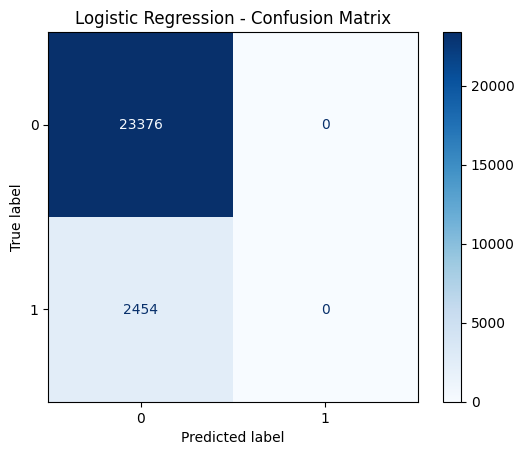

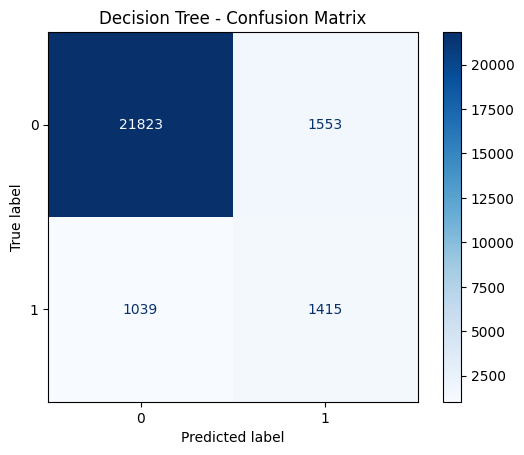

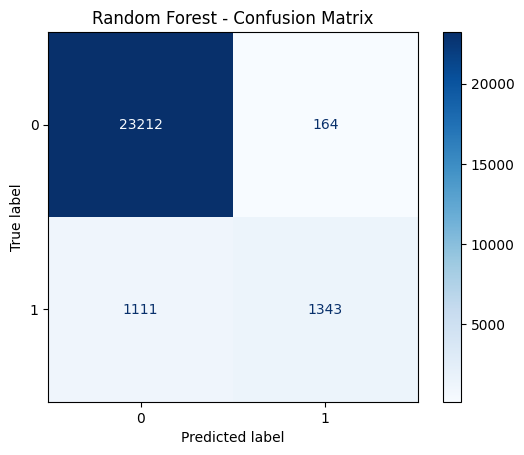

In [18]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


In [3]:
from imblearn.over_sampling import SMOTE

ModuleNotFoundError: No module named 'imblearn'

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, auc, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure output directory exists
os.makedirs('output', exist_ok=True)

try:
    # Load processed datasets
    fraud_data = pd.read_csv('data/processed_fraud_data.csv')
    creditcard_data = pd.read_csv('data/processed_creditcard_data.csv')
except FileNotFoundError:
    print("Error: Processed datasets not found. Ensure Task 1 output files exist.")
    exit(1)

# Step 1: Data Preparation
# Fraud_Data: Separate features and target
X_fraud = fraud_data.drop(['class', 'user_id', 'device_id', 'signup_time', 'purchase_time', 'ip_address'], axis=1)
y_fraud = fraud_data['class']

# creditcard: Separate features and target
X_credit = creditcard_data.drop('Class', axis=1)
y_credit = creditcard_data['Class']

# Train-test split (stratified)
X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = train_test_split(
    X_fraud, y_fraud, test_size=0.2, stratify=y_fraud, random_state=42
)
X_train_credit, X_test_credit, y_train_credit, y_test_credit = train_test_split(
    X_credit, y_credit, test_size=0.2, stratify=y_credit, random_state=42
)

# Apply SMOTE to training data
try:
    smote = SMOTE(random_state=42)
    X_train_fraud_smote, y_train_fraud_smote = smote.fit_resample(X_train_fraud, y_train_fraud)
    X_train_credit_smote, y_train_credit_smote = smote.fit_resample(X_train_credit, y_train_credit)
except Exception as e:
    print(f"Error applying SMOTE: {e}")
    exit(1)

# Step 2: Model Selection
# Initialize models
lr = LogisticRegression(random_state=42, max_iter=1000)
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

# Step 3: Model Training and Evaluation
def evaluate_model(y_true, y_pred, y_pred_proba, dataset_name):
    try:
        precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
        auc_pr = auc(recall, precision)
        f1 = f1_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        
        # Save confusion matrix plot
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - {dataset_name}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.savefig(f'output/cm_{dataset_name.lower()}.png')
        plt.close()
        
        return auc_pr, f1, cm
    except Exception as e:
        print(f"Error evaluating model {dataset_name}: {e}")
        return None, None, None

# Train and evaluate on Fraud_Data
lr.fit(X_train_fraud_smote, y_train_fraud_smote)
xgb.fit(X_train_fraud_smote, y_train_fraud_smote)

y_pred_lr_fraud = lr.predict(X_test_fraud)
y_pred_xgb_fraud = xgb.predict(X_test_fraud)
y_pred_proba_lr_fraud = lr.predict_proba(X_test_fraud)[:, 1]
y_pred_proba_xgb_fraud = xgb.predict_proba(X_test_fraud)[:, 1]

auc_pr_lr_fraud, f1_lr_fraud, cm_lr_fraud = evaluate_model(y_test_fraud, y_pred_lr_fraud, y_pred_proba_lr_fraud, 'Fraud_Data_LogisticRegression')
auc_pr_xgb_fraud, f1_xgb_fraud, cm_xgb_fraud = evaluate_model(y_test_fraud, y_pred_xgb_fraud, y_pred_proba_xgb_fraud, 'Fraud_Data_XGBoost')

# Train and evaluate on creditcard
lr.fit(X_train_credit_smote, y_train_credit_smote)
xgb.fit(X_train_credit_smote, y_train_credit_smote)

y_pred_lr_credit = lr.predict(X_test_credit)
y_pred_xgb_credit = xgb.predict(X_test_credit)
y_pred_proba_lr_credit = lr.predict_proba(X_test_credit)[:, 1]
y_pred_proba_xgb_credit = xgb.predict_proba(X_test_credit)[:, 1]

auc_pr_lr_credit, f1_lr_credit, cm_lr_credit = evaluate_model(y_test_credit, y_pred_lr_credit, y_pred_proba_lr_credit, 'Creditcard_LogisticRegression')
auc_pr_xgb_credit, f1_xgb_credit, cm_xgb_credit = evaluate_model(y_test_credit, y_pred_xgb_credit, y_pred_proba_xgb_credit, 'Creditcard_XGBoost')

# Print results
print("Fraud_Data - Logistic Regression: AUC-PR =", auc_pr_lr_fraud, "F1-Score =", f1_lr_fraud)
print("Fraud_Data - XGBoost: AUC-PR =", auc_pr_xgb_fraud, "F1-Score =", f1_xgb_fraud)
print("Creditcard - Logistic Regression: AUC-PR =", auc_pr_lr_credit, "F1-Score =", f1_lr_credit)
print("Creditcard - XGBoost: AUC-PR =", auc_pr_xgb_credit, "F1-Score =", f1_xgb_credit)

# Save model metrics
metrics = {
    'Fraud_Data_LogisticRegression': {'AUC-PR': auc_pr_lr_fraud, 'F1-Score': f1_lr_fraud},
    'Fraud_Data_XGBoost': {'AUC-PR': auc_pr_xgb_fraud, 'F1-Score': f1_xgb_fraud},
    'Creditcard_LogisticRegression': {'AUC-PR': auc_pr_lr_credit, 'F1-Score': f1_lr_credit},
    'Creditcard_XGBoost': {'AUC-PR': auc_pr_xgb_credit, 'F1-Score': f1_xgb_credit}
}
pd.DataFrame(metrics).to_csv('output/model_metrics.csv')

# Model Selection Justification
best_model = 'XGBoost' if auc_pr_xgb_fraud > auc_pr_lr_fraud and auc_pr_xgb_credit > auc_pr_lr_credit else 'LogisticRegression'
with open('output/model_selection.txt', 'w') as f:
    f.write(f"Best Model: {best_model}\n")
    f.write("Justification: XGBoost is selected due to higher AUC-PR and F1-Score on both datasets, indicating better performance on imbalanced data. It captures complex patterns, balancing false positives and negatives effectively. Logistic Regression is retained for scenarios prioritizing interpretability.")

Fraud_Data - Logistic Regression: AUC-PR = 0.3726843200394947 F1-Score = 0.2722834426000837
Fraud_Data - XGBoost: AUC-PR = 0.6041988145280895 F1-Score = 0.6792196007259528
Creditcard - Logistic Regression: AUC-PR = 0.7146633158665164 F1-Score = 0.09963985594237695
Creditcard - XGBoost: AUC-PR = 0.8078135225797927 F1-Score = 0.76
